In [1]:
# PAV association with perenniality
# author: Sheng-Kai Hsu
# created: 2023.09.14
# last edited: 2023.09.14


In [2]:
rm(list=ls())
library(limma)
library(scales)
library(pheatmap)
library(ape)
require(reshape2)
library(dplyr)
library(phytools)
library(geiger)
library(ggtree)
library(stringr)
library(qqman)
library(parallel)

require(rMVP)      # R version of the MVP package
source("/workdir/sh2246/p_evolBNI/src/S01_phyloK.R")

Loading required package: reshape2


Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:scales’:

    rescale


ggtree v3.4.4 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published research, please cite
the appropriate paper(s):

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-Yuk Lam.
ggtree: an R package for visualization and annotation of phylogenetic
trees with their covariates and other associated data. Methods in
Ecology and Evolution. 2017, 8(1):28-36. doi:10.1111/2041-210X.12628

Guangchuang Yu.  Data Integration, Manipulation and Visualization of
Phylogenetic Trees (1st edition). Chapman and Hall/CRC. 202

In [3]:
GWAS=function(P,G,K,map,nPC=0,method="GLM",CV=NULL){
  # preparing the inputs (PAV, K matrix and map) according to MVP needs
  
  genotype_PAV     = as.big.matrix(G) # dimension: PAV x samples
  genotype_Kmatrix = as.big.matrix(K)           # dimension: samples x samples
  
  # perenniality  # data.frame, dimension: samples x (sample id + traits)
  # map_panand2   # data.frame, dimension: PAVs x 3 (gene, chr and position)
  
  #head(map_panand2)
  #map_panand2$chr = as.numeric(gsub(map_panand2$chr,pattern = 'chr',replacement = '')) # ignore it. does not matter
  
  GWAS_perenniality <- rMVP::MVP(
    # Data Inputs 
    phe  = P, 
    geno = genotype_PAV,
    K    = genotype_Kmatrix,
    map  = map,
    CV.GLM = CV, CV.MLM = CV,  
    
    # Method 
    method=method, 
    
    # Number of Principal components for each mode ---
    nPC.GLM = nPC, nPC.MLM = nPC,
    
    # Threshold 
    permutation.threshold = F, threshold = 0.05,
    
    # Outputs and computing parameters
    file.output=F, ncpus=8)
}


In [4]:
trait = read.csv("/workdir/hackathon_202309/data/Perennitality_Numeric_Phenotype_325Taxa.csv",header = T,row.names = 1)

In [5]:
pav = t(read.table("/workdir/hackathon_202309/output/PAV/Zm00001eb_pav.txt"))
pav.dist = t(read.table("/workdir/hackathon_202309/output/distPAV/distPAV.txt"))

In [6]:
rownames(pav) = gsub("\\.","-",rownames(pav))
rownames(pav.dist) = gsub("\\.","-",rownames(pav.dist))

In [7]:
simPav = list() 
freq = seq(0.1,0.8,0.1)
for (i in 1:8){
    tmp.flist = list.files(paste0("/workdir/hackathon_202309/output/simPAV/lifeHistory/freq_",freq[i]),full.names = T)
    simPav[[i]] = lapply(tmp.flist,function(x) t(read.table(x)))
    simPav[[i]] = lapply(simPav[[i]],function(x) {
        rownames(x) = gsub("\\.","-",rownames(x))
        return(x)
    })
}

# simPav[[1]][[1]] 

In [8]:
K = read.table("/workdir/hackathon_202309/output/Kphylo.txt")

In [9]:
colnames(K) = rownames(K)

In [10]:
dim(pav)
dim(K)
dim(simPav[[1]][[1]])
dim(trait)

[1]  393 5000

[1] 331 331

[1] 271  10

[1] 325   2

In [11]:
common_row = Reduce(intersect,list(rownames(pav),rownames(simPav[[1]][[1]]),rownames(trait),rownames(K)))

In [12]:
length(common_row)

[1] 271

In [13]:
pav_filtered = pav[common_row,]
pav.dist_filtered = pav.dist[common_row,]
trait_filtered = trait[common_row,]
K_filtered = K[common_row,common_row]

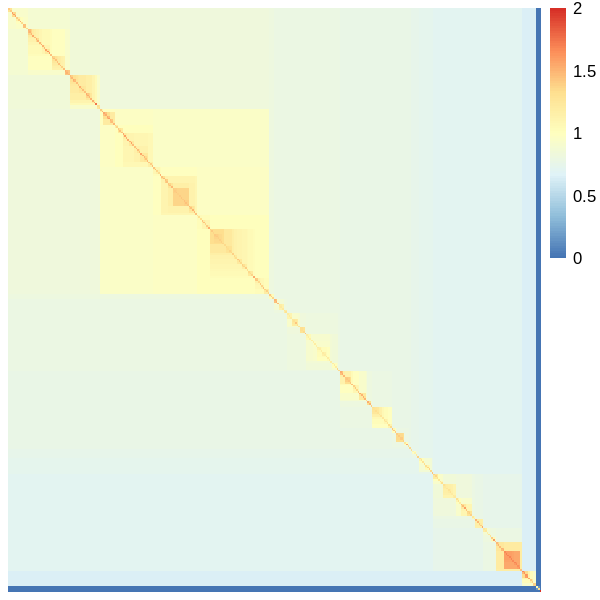

In [23]:
options(repr.plot.width=5, repr.plot.height=5)
pheatmap(K,show_rownames = F,show_colnames = F,cluster_rows = F,cluster_cols = F)

In [14]:
colnames(trait_filtered) = c("sample","lifeHistory")

In [15]:
gff=read.delim("/workdir/hackathon_202309/data/Zm-B73-REFERENCE-NAM-5.0_Zm00001eb.1.gff3",header = F,skip = 4)
gff_genePos=gff[gff$V3=="mRNA",]
rownames(gff_genePos)=gsub("ID=","",strsplit2(gff_genePos$V9,";")[,1])

In [16]:
head(gff)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,chr1,assembly,chromosome,1,308452471,.,.,.,ID=1;Name=chromosome:Zm-B73-REFERENCE-NAM-5.0:1:1:308452471:1
2,chr1,NAM,gene,34617,40204,.,+,.,ID=Zm00001eb000010;biotype=protein_coding;logic_name=cshl_gene
3,chr1,NAM,mRNA,34617,40204,.,+,.,ID=Zm00001eb000010_T001;Parent=Zm00001eb000010;biotype=protein_coding;transcript_id=Zm00001eb000010_T001;canonical_transcript=1
4,chr1,NAM,five_prime_UTR,34617,34721,.,+,.,Parent=Zm00001eb000010_T001
5,chr1,NAM,exon,34617,35318,.,+,.,Parent=Zm00001eb000010_T001;Name=Zm00001eb000010_T001.exon.1;ensembl_end_phase=0;ensembl_phase=0;exon_id=Zm00001eb000010_T001.exon.1;rank=1
6,chr1,NAM,exon,36037,36174,.,+,.,Parent=Zm00001eb000010_T001;Name=Zm00001eb000010_T001.exon.2;ensembl_end_phase=0;ensembl_phase=0;exon_id=Zm00001eb000010_T001.exon.2;rank=2


In [24]:
#position mapping and PAV filtering
map = data.frame(gene=rownames(gff_genePos),chr = gff_genePos[,1],POS=gff_genePos[,4])
map=map[grep("chr",map$chr),]
map$gene = as.character(map$gene)
map = map [map$gene %in% colnames(pav_filtered),]
map4 = map [map$gene %in% colnames(pav.dist_filtered),]

In [25]:
head(map)

,gene,chr,POS
,<chr>,<chr>,<int>
9,Zm00001eb000080_T001,chr1,200262
14,Zm00001eb000150_T001,chr1,328087
19,Zm00001eb000180_T001,chr1,551078
30,Zm00001eb000230_T002,chr1,1022421
46,Zm00001eb000360_T001,chr1,1538240
61,Zm00001eb000460_T001,chr1,2009997


In [26]:
PAVUsed=pav_filtered
PAVUsed=PAVUsed[,colSums(PAVUsed)>ncol(PAVUsed)*.01&colSums(PAVUsed)<ncol(PAVUsed)*.99]

map2=map[map$gene%in%colnames(PAVUsed),]
PAVUsed=PAVUsed[,map2$gene]

In [27]:
PAVUsed.dist=pav.dist_filtered
PAVUsed.dist=PAVUsed.dist[,colSums(PAVUsed.dist)>ncol(PAVUsed.dist)*.01&colSums(PAVUsed.dist)<ncol(PAVUsed.dist)*.99]

map5=map4[map4$gene%in%colnames(PAVUsed.dist),]
PAVUsed.dist=PAVUsed.dist[,map5$gene]

In [28]:
dim(PAVUsed.dist)

[1]  271 4775

In [29]:
res=GWAS(trait_filtered,t(PAVUsed),K_filtered,map2,method = c("GLM","MLM"))
res2=GWAS(trait_filtered,t(PAVUsed.dist),K_filtered,map5,method = c("GLM","MLM"))

Warning message in as.big.matrix(K):
“Coercing data.frame to matrix via factor level numberings.”


====================== Welcome to MVP ======================
      A Memory-efficient, Visualization-enhanced, and       
             Parallel-accelerated Tool For GWAS             
                    __  __  __   __  ___                    
                   |  \/  | \ \ / / | _ \                   
                   | |\/| |  \ V /  |  _/                   
                   |_|  |_|   \_/   |_|     Version: 1.0.6  
  Designed and Maintained by Lilin Yin, Haohao Zhang, and   
  Xiaolei Liu                                               
  Contributors: Zhenshuang Tang, Jingya Xu, Dong Yin,       
  Zhiwu Zhang, Xiaohui Yuan, Mengjin Zhu, Shuhong Zhao,     
  Xinyun Li                                                 
  Contact: xiaoleiliu@mail.hzau.edu.cn                      
Start: 2023-09-15 12:52:20 
Input data has 271 individuals, 4782 markers 
Analyzed trait: lifeHistory 
Number of threads used: 8 
Eigen Decomposition on GRM 
-------------------------GWAS Start--------------

Warning message in as.big.matrix(K):
“Coercing data.frame to matrix via factor level numberings.”


====================== Welcome to MVP ======================
      A Memory-efficient, Visualization-enhanced, and       
             Parallel-accelerated Tool For GWAS             
                    __  __  __   __  ___                    
                   |  \/  | \ \ / / | _ \                   
                   | |\/| |  \ V /  |  _/                   
                   |_|  |_|   \_/   |_|     Version: 1.0.6  
  Designed and Maintained by Lilin Yin, Haohao Zhang, and   
  Xiaolei Liu                                               
  Contributors: Zhenshuang Tang, Jingya Xu, Dong Yin,       
  Zhiwu Zhang, Xiaohui Yuan, Mengjin Zhu, Shuhong Zhao,     
  Xinyun Li                                                 
  Contact: xiaoleiliu@mail.hzau.edu.cn                      
Start: 2023-09-15 12:52:24 
Input data has 271 individuals, 4775 markers 
Analyzed trait: lifeHistory 
Number of threads used: 8 
Eigen Decomposition on GRM 
-------------------------GWAS Start--------------

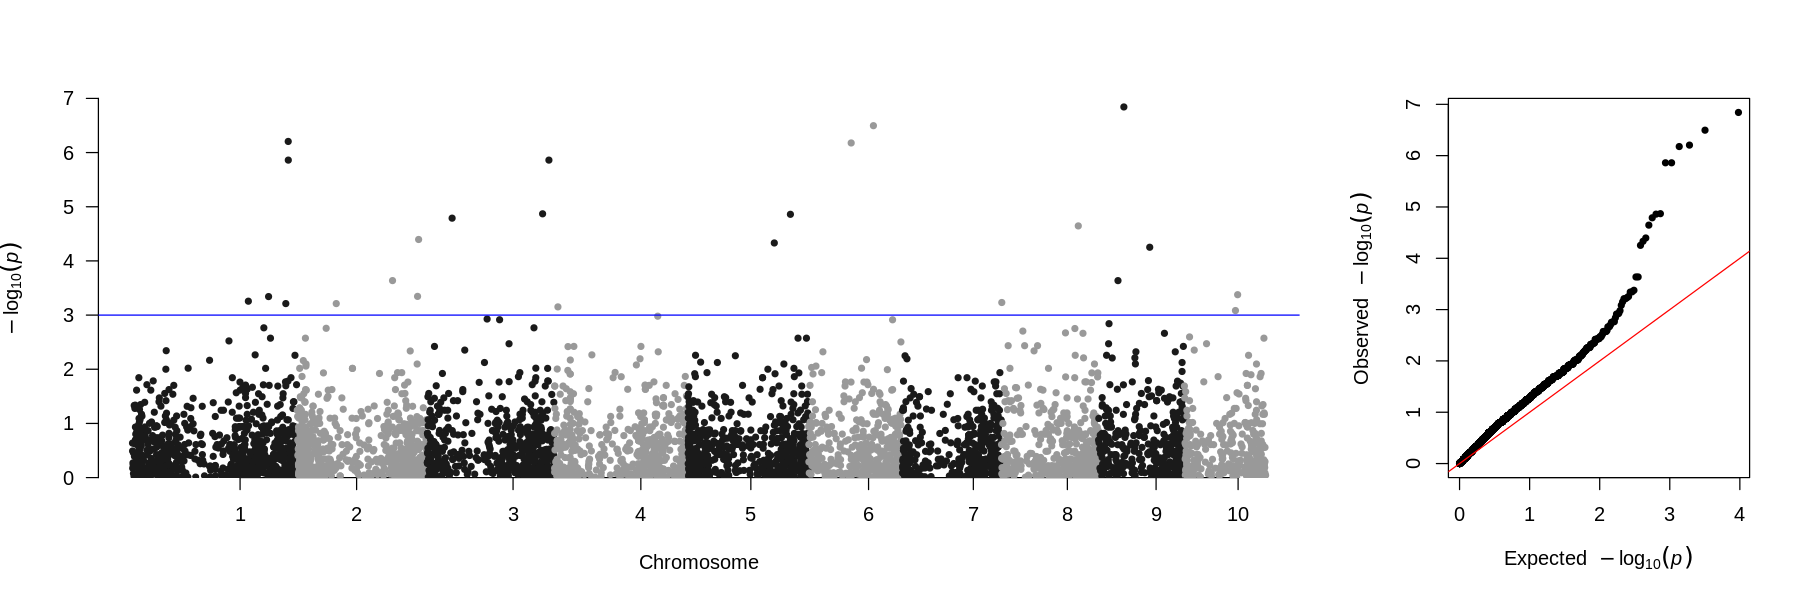

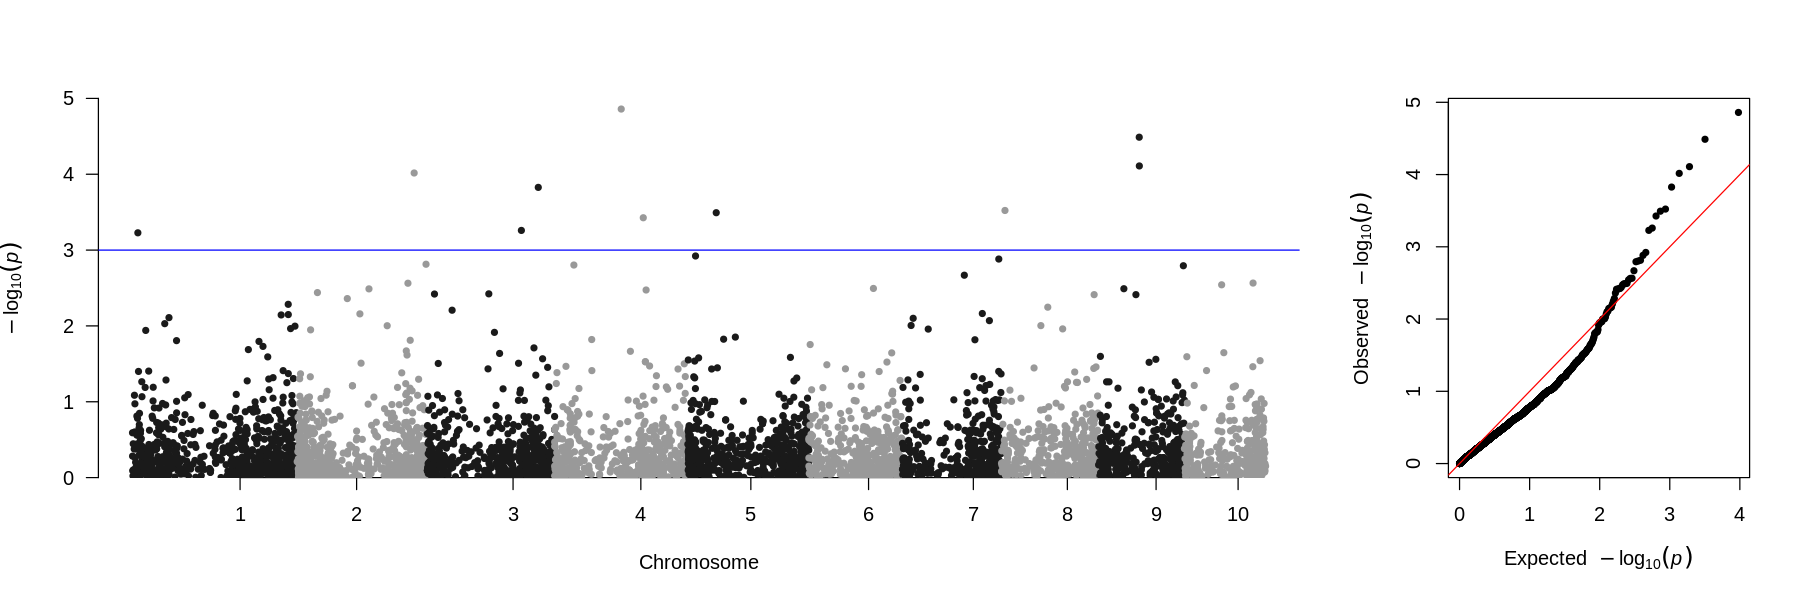

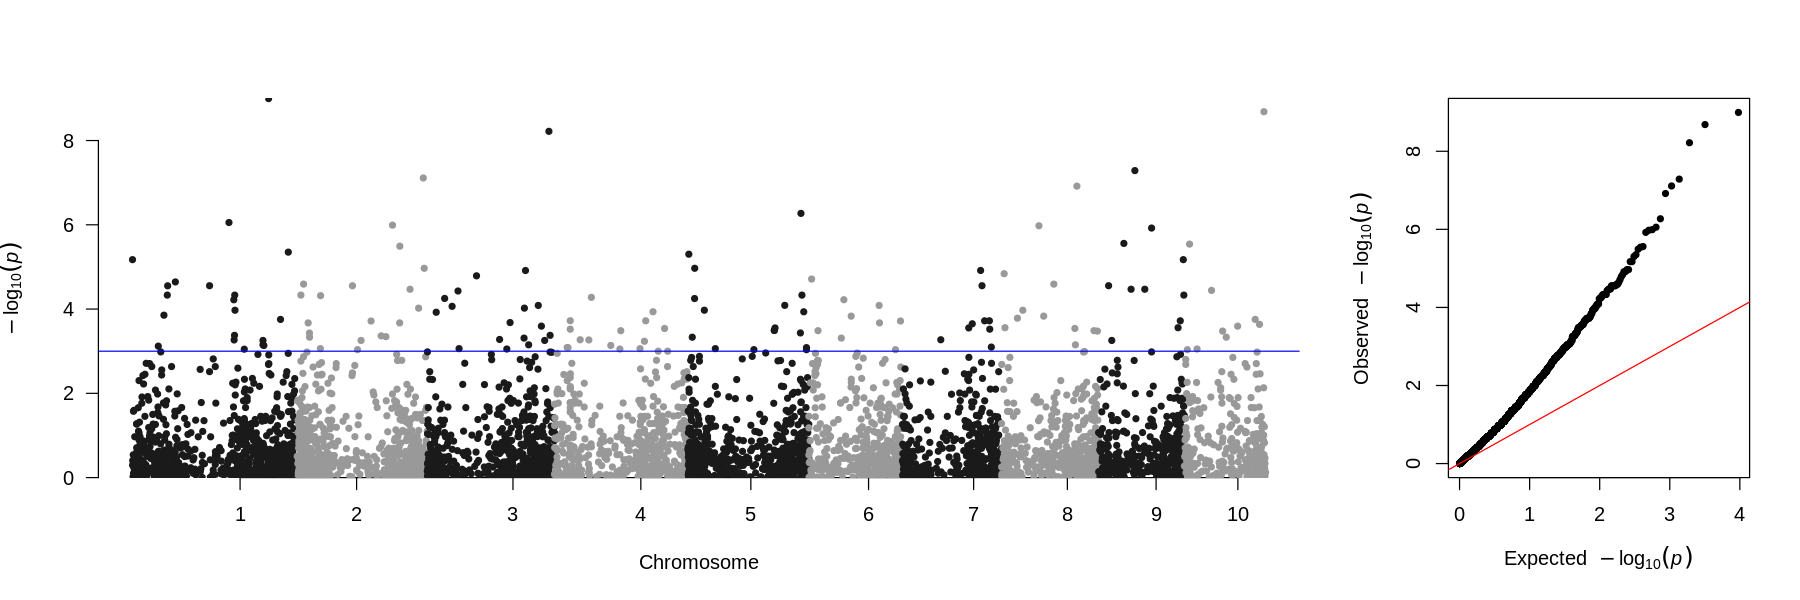

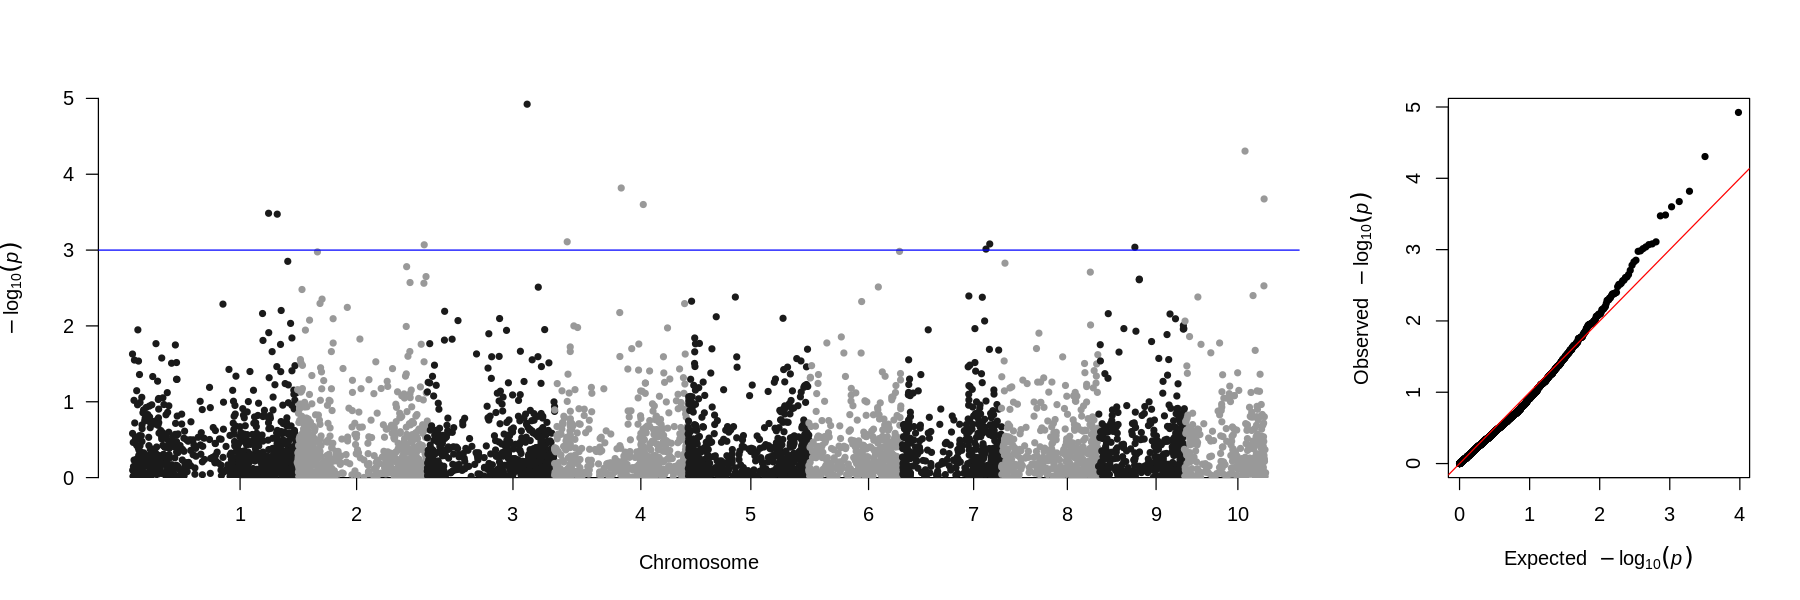

In [30]:
res_glm=data.frame(Chr=as.numeric(gsub("chr","",map2$chr)),BP=map2$POS,P=as.numeric(res$glm.results[,3]),Gene=map2$gene)
res_mlm=data.frame(Chr=as.numeric(gsub("chr","",map2$chr)),BP=map2$POS,P=as.numeric(res$mlm.results[,3]),Gene=map2$gene)

res_glm2=data.frame(Chr=as.numeric(gsub("chr","",map5$chr)),BP=map5$POS,P=as.numeric(res2$glm.results[,3]),Gene=map5$gene)
res_mlm2=data.frame(Chr=as.numeric(gsub("chr","",map5$chr)),BP=map5$POS,P=as.numeric(res2$mlm.results[,3]),Gene=map5$gene)


options(repr.plot.width=15, repr.plot.height=5)
layout(matrix(1:2,nrow = 1,byrow =T),widths = c(3,1))
# layout.show(2)
manhattan(na.omit(res_glm),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
qq(as.numeric(res$glm.results[,3]))
manhattan(na.omit(res_mlm),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
qq(as.numeric(res$mlm.results[,3]))

manhattan(na.omit(res_glm2),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
qq(as.numeric(res2$glm.results[,3]))
manhattan(na.omit(res_mlm2),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
qq(as.numeric(res2$mlm.results[,3]))



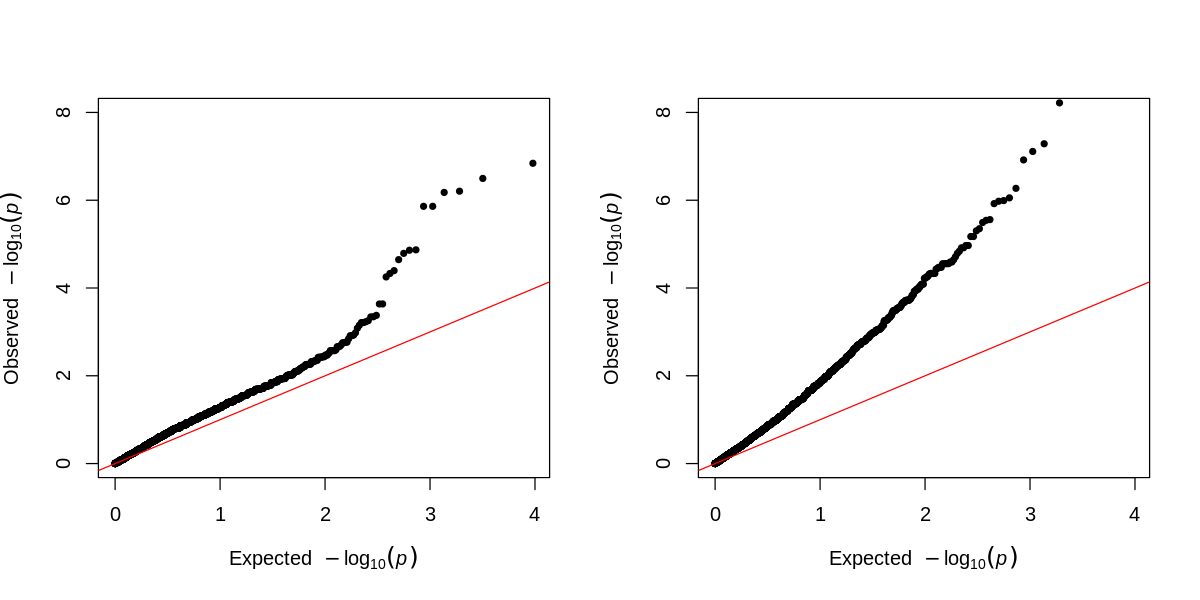

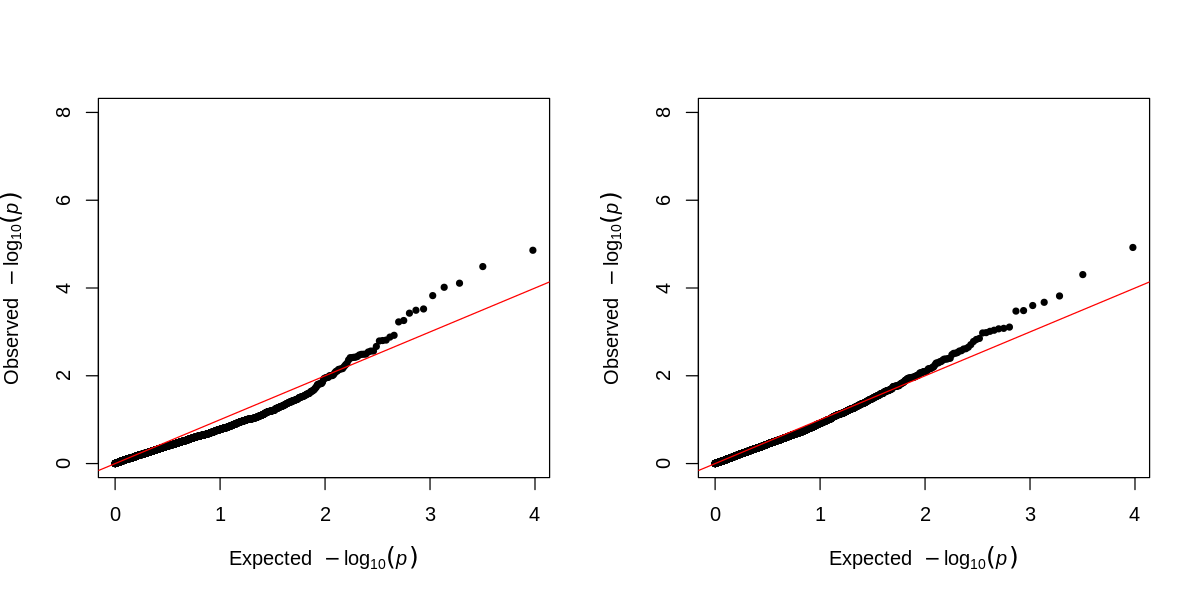

In [81]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2))
qq(as.numeric(res$glm.results[,3]),ylim =c(0,8))
qq(as.numeric(res2$glm.results[,3]),ylim =c(0,8))

qq(as.numeric(res$mlm.results[,3]),ylim =c(0,8))
qq(as.numeric(res2$mlm.results[,3]),ylim =c(0,8))

[1] 0.3116765

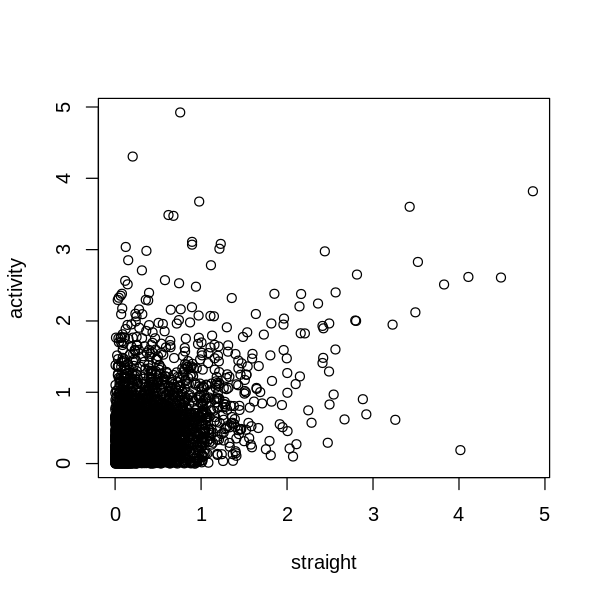

In [31]:
idx = intersect(map2$gene,map5$gene)
options(repr.plot.width=5, repr.plot.height=5)
plot(-log10(res_mlm$P[map2$gene%in%idx]),-log10(res_mlm2$P[map5$gene%in%idx]),xlab = "straight",ylab = "activity")
cor(res_mlm$P[map2$gene%in%idx],res_mlm2$P[map5$gene%in%idx],use = "complete",method = "spearman")

In [55]:
summary(-log10(LRT_res[overlap,]$p))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   2.770     Inf   5.394     Inf 

In [ ]:
dim(res_mlm)
dim(res_mlm2)

In [89]:
source('https://raw.githubusercontent.com/gcostaneto/envFeatures/main/src/fitMLRGEA_fun.R')
library(doParallel)

gPC=eigen(K_filtered)$vectors[,1:2]

rownames(gPC)=common_row
colnames(gPC)=c("gPC1","gPC2")

traitMatrix = data_frame(lifeHistory=trait_filtered[,2],fake = rep(1,271))
rownames(traitMatrix) = trait_filtered$sample

logRegRes =fitMLRGEA(geno_Y = PAVUsed,envo_X = traitMatrix,
                     #geno_X    = gPCs,
                     n.core    = 40,parallel  = TRUE,verbose   = TRUE,
                     output.path = "/workdir/hackathon_202309/output/test/")

Warning message:
“Setting row names on a tibble is deprecated.”

Multinomial Logistic Regresion for Genomic-Environment Associations (MLR-GEA)

fitMLRGEA() function, v0.0.1 (Sep 15 2023)

-========================================================================

started at ......2023-09-15 15:22:49


ended at ......2023-09-15 15:23:06


saving files at....../workdir/hackathon_202309/output/test/




[1] 0.9994908

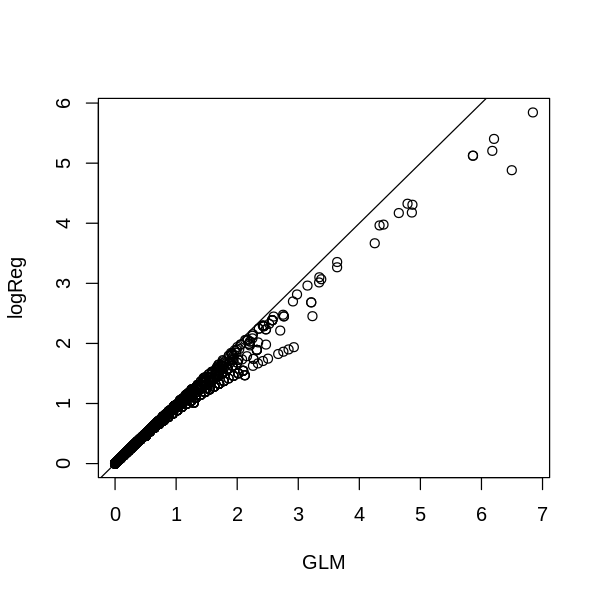

In [93]:
options(repr.plot.width=5, repr.plot.height=5)
plot(-log10(res_glm$P),logRegRes$partial_log10_lifeHistory,xlab = "GLM",ylab = "logReg")
abline(a=0,b=1)
cor(logRegRes$partial_log10_lifeHistory,-log10(res_glm$P),use = "complete",method = "spearman")

In [ ]:
resList = list()
for (i in 1:8){
    resList[[i]]=lapply(1:100,function(x){
        PAVplus = cbind(PAVUsed,simPav[[i]][[x]])
        map3 = rbind(map2,data.frame(gene = paste0("simPAV",0:9),chr = "chr11",POS = 1:10))
        out = GWAS(trait_filtered,t(PAVplus),K_filtered,map3,method = c("GLM","MLM"))
        return(out)
    })  
}

In [ ]:
resList[[1]][[1]]

In [ ]:
dp.glm = list()
dp.mlm = list()
ap.glm = list()
ap.mlm = list()
for (i in 1:8){
    dp.glm[[i]] = rep(0,100)
    dp.mlm[[i]] = rep(0,100)
    ap.glm[[i]] = rep(0,100)
    ap.mlm[[i]] = rep(0,100)
    for(j in 1:100){
        dp.glm[[i]][[j]] = sum(p.adjust(resList[[i]][[j]][[2]][,3],"BH")[-(1:4782)]<0.05,na.rm=T)
        dp.mlm[[i]][[j]] = sum(p.adjust(resList[[i]][[j]][[3]][,3],"BH")[-(1:4782)]<0.05,na.rm=T)
        ap.glm[[i]][[j]] = sum(p.adjust(resList[[i]][[j]][[2]][,3],"BH")<0.05,na.rm=T)
        ap.mlm[[i]][[j]] = sum(p.adjust(resList[[i]][[j]][[3]][,3],"BH")<0.05,na.rm=T)
    }        
}



In [ ]:
dpTabGLM=simplify2array(dp.glm)
dpTabMLM=simplify2array(dp.mlm)
apTabGLM=simplify2array(ap.glm)
apTabMLM=simplify2array(ap.mlm)

In [ ]:
dAvg = cbind(apply(dpTabGLM/10,2,mean),apply(dpTabMLM/10,2,mean))
sAvg = cbind(apply(dpTabGLM/apTabGLM,2,mean),apply(dpTabMLM/apTabMLM,2,mean))

In [ ]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow =c(1,2))
plot(freq,dAvg[,1],type ="b",lty = 2,lwd = 2,ylab =  "Detection Power",ylim = c(0,1))
points(freq,dAvg[,2],type ="b",lty = 1,lwd = 2)
legend("bottomright",lwd =2 ,lty = c(2,1),legend = c("GLM","MLM"))
plot(freq,sAvg[,1],type ="b",lty = 2,lwd = 2,ylab =  "Sensitivity",ylim = c(0,1))
points(freq,sAvg[,2],type ="b",lty = 1,lwd = 2)
legend("bottomright",lwd =2 ,lty = c(2,1),legend = c("GLM","MLM"))

In [ ]:
myqq=function(x,highlight,...){
  set.seed(100)
  tmp=cbind(x,highlight)
  tmp_nona=na.omit(tmp)
  tmp_ordered=tmp_nona[order(tmp_nona[,1]),]
  tmp_ordered=cbind(tmp_ordered,sort(runif(nrow(tmp_ordered))))
  
  plot(-log10(tmp_ordered[,c(3,1)]),xlab=expression(-log[10](p[exp.])),ylab=expression(-log[10](p[obs.])),...)
  points(-log10(tmp_ordered[tmp_ordered[,2]==1,c(3,1)]),col="red",pch=19)
  abline(a=0,b=1,col="red")
}

In [ ]:
par(mfrow = c(1,2))
myqq(resList[[1]][[1]][[2]][,3],1:4792%in%4783:4792)
myqq(resList[[1]][[1]][[3]][,3],1:4792%in%4783:4792)

myqq(resList[[2]][[1]][[2]][,3],1:4792%in%4783:4792)
myqq(resList[[2]][[1]][[3]][,3],1:4792%in%4783:4792)

myqq(resList[[3]][[1]][[2]][,3],1:4792%in%4783:4792)
myqq(resList[[3]][[1]][[3]][,3],1:4792%in%4783:4792)